<div style="
    direction: rtl;
    text-align: right;
    font-family: 'Vazirmatn', 'IRANSans', sans-serif;
    max-width: 760px;
    margin: 14px auto;
    padding: 16px 18px 16px 14px;
    border-radius: 18px;
    background: #ffffff;
    border: 1px solid #e5e7eb;
    border-right: 6px solid #2563eb;
    box-shadow: 0 6px 18px rgba(0, 0, 0, 0.045);
">
  <div style="margin-left: 18px;">
    <div style="
        display: inline-block;
        font-size: 11px;
        font-weight: 700;
        color: #1d4ed8;
        background: #eff6ff;
        padding: 4px 11px;
        border-radius: 999px;
        margin-bottom: 10px;
    ">
      دوره مبانی هوش مصنوعی
    </div>
    <div style="
        font-size: 24px;
        font-weight: 900;
        color: #111827;
        line-height: 1.4;
        margin-bottom: 6px;
    ">
      یادگیری ماشین با نظارت | Supervised Machine Learning
    </div>
    <div style="
        width: 56px;
        height: 3px;
        background: linear-gradient(90deg, #2563eb, #60a5fa);
        border-radius: 999px;
        margin-bottom: 10px;
    "></div>
    <div style="
        font-size: 15px;
        font-weight: 700;
        color: #374151;
        margin-bottom: 4px;
    ">
      دبیرستان دوره اول علامه حلی ۵ تهران
    </div>
    <div style="
        font-size: 14px;
        color: #4b5563;
        line-height: 1.7;
        margin-bottom: 10px;
    ">
    <span style="font-weight: 700; color: #111827;">پارسا صدری</span> و <span style="font-weight: 700; color: #111827;">علیرضا سپهری</span>
    </div>
    <div style="
        display: inline-block;
        font-size: 12px;
        color: #1e40af;
        background: #f0f9ff;
        padding: 4px 10px;
        border-radius: 999px;
        border: 1px solid #bae6fd;
    ">
      تابستان ۱۴۰۵
    </div>
  </div>
</div>


در این نوت‌بوک می‌خواهیم ببینیم کامپیوتر چطور با دیدن مثال‌های قبلی، یاد می‌گیرد برای داده‌های جدید پیش‌بینی انجام دهد.

در این مثال، از یک دیتاست معروف به نام **Iris** استفاده می‌کنیم.  
این دیتاست شامل اطلاعات چند گل است و هدف ما این است که مدل بتواند **نوع گل** را تشخیص دهد.

---

## چند واژه مهم

- **Dataset**: مجموعه داده
- **Feature**: ویژگی‌های هر داده
- **Label / Target**: جواب درست
- **Train Data**: داده‌ای که مدل با آن یاد می‌گیرد
- **Test Data**: داده‌ای که مدل با آن امتحان می‌شود
- **Model**: الگوریتمی که از داده یاد می‌گیرد
- **Fit**: آموزش دادن مدل
- **Predict**: پیش‌بینی کردن
- **Accuracy**: درصد پیش‌بینی‌های درست


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

## 1) بارگذاری داده

در این بخش، دیتاست Iris را بارگذاری می‌کنیم.

در این داده:
- `X` شامل ویژگی‌هاست. (Features)
- `y` شامل نوع گل‌هاست

In [2]:
iris = load_iris()

X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = pd.Series(iris.target, name="target")

print("نام ستون‌ها:")
print(X.columns.tolist())

print("\nابعاد داده:")
print(X.shape)

نام ستون‌ها:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

ابعاد داده:
(150, 4)


## 2) نگاه اولیه به داده

قبل از آموزش مدل، بهتر است کمی داده را بررسی کنیم.

چند کار ساده:
- دیدن چند سطر اول
- بررسی داده‌های خالی
- آشنایی با مقدارهای داده

In [3]:
X.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [4]:
X.isnull().sum()

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
dtype: int64

In [5]:
X.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


## 3) آشنایی با برچسب‌ها

در این مسئله، هر عدد نشان‌دهنده یک نوع گل است.

In [6]:
print("کلاس‌ها:", iris.target_names)

کلاس‌ها: ['setosa' 'versicolor' 'virginica']


![ML Concepts](https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcSIeZbmjf3VwKW7-Bz2gAGcOzX8z43PeFoToC09DKXiA0Imv9_HDeHX28c&s=10)

## 4) نمایش تصویری داده

حالا داده‌ها را روی نمودار می‌بینیم.

در این نمودار:
- هر نقطه یک گل است
- رنگ هر نقطه نوع گل را نشان می‌دهد

این نمودار کمک می‌کند بفهمیم بعضی گروه‌ها از هم قابل جدا شدن هستند.

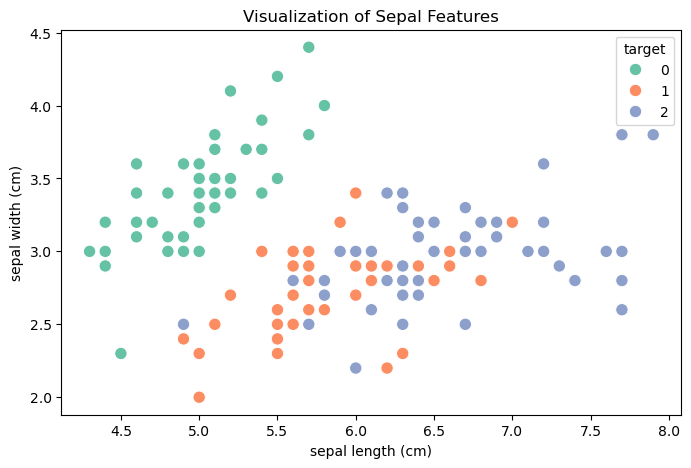

In [7]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x=X.iloc[:, 0], y=X.iloc[:, 1], hue=y, palette="Set2", s=80)

plt.xlabel(X.columns[0])
plt.ylabel(X.columns[1])
plt.title("Visualization of Sepal Features")
plt.show()

## 5) تقسیم داده به آموزش و آزمون

ما همه داده را یک‌جا به مدل نمی‌دهیم.

- بخش **Train** برای یادگیری مدل است
- بخش **Test** برای امتحان گرفتن از مدل است

اینجا 80 درصد داده‌ها برای آموزش و 20 درصد برای آزمون استفاده می‌شود.

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("تعداد داده‌های آموزشی:", X_train.shape[0])
print("تعداد داده‌های آزمایشی:", X_test.shape[0])

تعداد داده‌های آموزشی: 120
تعداد داده‌های آزمایشی: 30


## 6) مدل اول: Decision Tree

**Decision Tree**  یک درخت تصمیم است.  
مدل با پرسیدن سؤال‌های پشت‌سرهم، سعی می‌کند به جواب درست برسد.

مثلاً:
- آیا طول گلبرگ بیشتر از یک مقدار خاص است؟
- اگر بله، به یک شاخه برو
- اگر نه، به شاخه دیگر برو

In [9]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)
dt_acc = accuracy_score(y_test, dt_pred)

print("Decision Tree Accuracy:", dt_acc)

Decision Tree Accuracy: 1.0


## 7) مدل دوم: Random Forest

**Random Forest** یعنی به‌جای یک درخت، چندین درخت تصمیم داشته باشیم.

هر درخت یک رأی می‌دهد و در آخر، جواب نهایی با رأی‌گیری انتخاب می‌شود.

به زبان ساده:
- Decision Tree = یک درخت
- Random Forest = یک جنگل از درخت‌ها

In [10]:
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_acc)

Random Forest Accuracy: 1.0


## 8) مدل سوم: KNN

**KNN** به نزدیک‌ترین نمونه‌ها نگاه می‌کند.

یعنی وقتی یک داده جدید می‌بیند، بررسی می‌کند که شبیه کدام داده‌های قبلی است و بر اساس همسایه‌های نزدیک، تصمیم می‌گیرد.

In [11]:
knn_model = KNeighborsClassifier()
knn_model.fit(X_train, y_train)

knn_pred = knn_model.predict(X_test)
knn_acc = accuracy_score(y_test, knn_pred)

print("KNN Accuracy:", knn_acc)

KNN Accuracy: 1.0


## 9) مدل چهارم: Logistic Regression

**Logistic Regression** مدلی است که سعی می‌کند از روی ویژگی‌ها، احتمال هر کلاس را حدس بزند.

ما در این جلسه وارد جزئیات ریاضی آن نمی‌شویم.  
فقط می‌خواهیم ببینیم که این مدل هم مثل بقیه:
- آموزش می‌بیند
- پیش‌بینی می‌کند
- و قابل مقایسه است

In [12]:
lr_model = LogisticRegression(max_iter=200)
lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)
lr_acc = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy:", lr_acc)

Logistic Regression Accuracy: 1.0


## 10) مدل پنجم: SVM

**SVM** سعی می‌کند بین گروه‌های مختلف، یک مرز خوب پیدا کند تا داده‌ها بهتر از هم جدا شوند.

این مدل هم یکی از مدل‌های معروف یادگیری ماشین است.

In [13]:
svm_model = SVC()
svm_model.fit(X_train, y_train)

svm_pred = svm_model.predict(X_test)
svm_acc = accuracy_score(y_test, svm_pred)

print("SVM Accuracy:", svm_acc)

SVM Accuracy: 1.0


In [14]:
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_digits

## 11) دیتاست Digits
در Iris مدل‌ها به دقت 100% رسیدند. برای دیدن تفاوت واقعی، از دیتاست **اعداد دست‌نویس** استفاده می‌کنیم که پیچیده‌تر است.

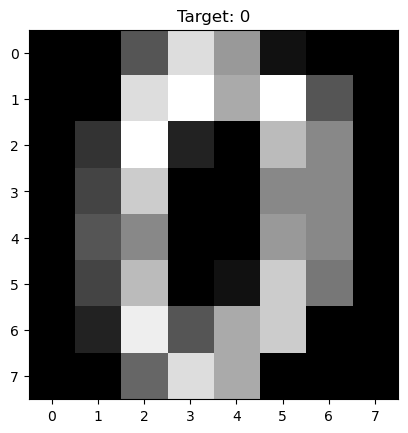

In [26]:
digits = load_digits()
X_dig, y_dig = digits.data, digits.target

plt.imshow(digits.images[0], cmap='gray')
plt.title(f"Target: {y_dig[0]}")
plt.show()

## 4) آموزش و مقایسه نهایی
در این بخش داده‌ها را **استاندارد** می‌کنیم تا مدل‌هایی مثل SVM و KNN بهتر کار کنند.

In [22]:
models = {
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "KNN": KNeighborsClassifier(),
    "Logistic Regression": LogisticRegression(max_iter=200),
    "SVM": SVC()
}

# تقسیم داده
Xd_train, Xd_test, yd_train, yd_test = train_test_split(X_dig, y_dig, test_size=0.2, random_state=42)

# استانداردسازی
scaler = StandardScaler()
Xd_train_s = scaler.fit_transform(Xd_train)
Xd_test_s = scaler.transform(Xd_test)

results = []
for name, model in models.items():
    X_train_use = Xd_train_s if name in ["KNN", "Logistic Regression", "SVM"] else Xd_train
    X_test_use = Xd_test_s if name in ["KNN", "Logistic Regression", "SVM"] else Xd_test
    
    model.fit(X_train_use, yd_train)
    acc = accuracy_score(yd_test, model.predict(X_test_use))
    results.append([name, acc])

# جدول نتایج
df_res = pd.DataFrame(results, columns=["Model", "Accuracy"]).sort_values(by="Accuracy", ascending=False)
df_res

,Model,Accuracy
4,SVM,0.980556
1,Random Forest,0.977778
2,KNN,0.975000
3,Logistic Regression,0.972222
0,Decision Tree,0.841667


## 5) تحلیل خطا (Confusion Matrix)
بیایید ببینیم بهترین مدل در تشخیص کدام اعداد بیشتر اشتباه کرده است.

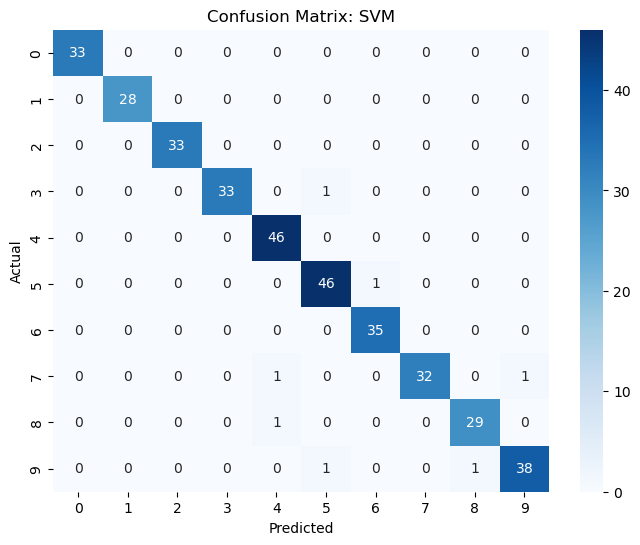

In [23]:
# رسم ماتریس برای بهترین مدل (اولین ردیف جدول بالا)
best_model_name = df_res.iloc[0]["Model"]
best_model = models[best_model_name]

# پیش‌بینی
X_test_final = Xd_test_s if best_model_name in ["KNN", "Logistic Regression", "SVM"] else Xd_test
y_pred = best_model.predict(X_test_final)

# رسم
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(yd_test, y_pred), annot=True, cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix: {best_model_name}")
plt.show()

In [18]:
from IPython.display import HTML

HTML("""
<style>
.jp-RenderedMarkdown, 
.rendered_html, 
.jp-MarkdownOutput {
    direction: rtl !important;
    text-align: right !important;
    font-family: "Vazirmatn", "Vazir", sans-serif !important;
    line-height: 1.8 !important;
}
.jp-RenderedMarkdown p, 
.jp-RenderedMarkdown li, 
.jp-RenderedMarkdown h1, 
.jp-RenderedMarkdown h2, 
.jp-RenderedMarkdown h3, 
.jp-RenderedMarkdown h4, 
.jp-RenderedMarkdown div,
.rendered_html p, 
.rendered_html li, 
.rendered_html h1, 
.rendered_html h2, 
.rendered_html h3 {
    direction: rtl !important;
    text-align: right !important;
    font-family: "Vazirmatn", "Vazir", sans-serif !important;
}
.jp-RenderedMarkdown ul, 
.jp-RenderedMarkdown ol,
.rendered_html ul, 
.rendered_html ol {
    padding-right: 2em !important;
    padding-left: 0 !important;
}
</style>
""")

## جمع‌بندی
- **Decision Tree:** سریع و ساده اما گاهی کم‌دقت.
- **Random Forest:** یکی از قوی‌ترین مدل ها (ترکیب چند درخت).
- **KNN:** بر اساس شباهت به همسایه‌ها.
- **SVM و Logistic Regression:** مدل‌های ریاضیاتی برای پیدا کردن مرز داده‌ها.

In [20]:
from IPython.display import HTML

HTML("""
<style>
.jp-RenderedMarkdown, 
.rendered_html, 
.jp-MarkdownOutput {
    direction: rtl !important;
    text-align: right !important;
    font-family: "Vazirmatn", "Vazir", sans-serif !important;
    line-height: 1.8 !important;
}
.jp-RenderedMarkdown p, 
.jp-RenderedMarkdown li, 
.jp-RenderedMarkdown h1, 
.jp-RenderedMarkdown h2, 
.jp-RenderedMarkdown h3, 
.jp-RenderedMarkdown h4, 
.jp-RenderedMarkdown div,
.rendered_html p, 
.rendered_html li, 
.rendered_html h1, 
.rendered_html h2, 
.rendered_html h3 {
    direction: rtl !important;
    text-align: right !important;
    font-family: "Vazirmatn", "Vazir", sans-serif !important;
}
.jp-RenderedMarkdown ul, 
.jp-RenderedMarkdown ol,
.rendered_html ul, 
.rendered_html ol {
    padding-right: 2em !important;
    padding-left: 0 !important;
}
</style>
""")